### Imports

In [1]:
import os
import time
import copy
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.models import vit_b_16, ViT_B_16_Weights

# Configurando GPU ou CPU
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo em uso: {device}")

Dispositivo em uso: cuda:0


### Transformações e Carregamento de Dados

In [ ]:
base_dir = '../../chest_xray'
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')

data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

full_train_dataset = datasets.ImageFolder(train_dir, transform=data_transforms['train'])
val_base_dataset = datasets.ImageFolder(train_dir, transform=data_transforms['val']) 
test_dataset = datasets.ImageFolder(test_dir, transform=data_transforms['val'])

targets = full_train_dataset.targets
train_idx, val_idx = train_test_split(
    np.arange(len(targets)), test_size=0.2, stratify=targets, random_state=42
)

train_subset = Subset(full_train_dataset, train_idx)
val_subset = Subset(val_base_dataset, val_idx)

batch_size = 32
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

dataloaders = {'train': train_loader, 'val': val_loader}
dataset_sizes = {'train': len(train_subset), 'val': len(val_subset)}
class_names = full_train_dataset.classes

print(f"Treino: {dataset_sizes['train']} | Validação: {dataset_sizes['val']} | Teste: {len(test_dataset)}")

Treino: 4185 | Validação: 1047 | Teste: 624


### Visualização das Transformações

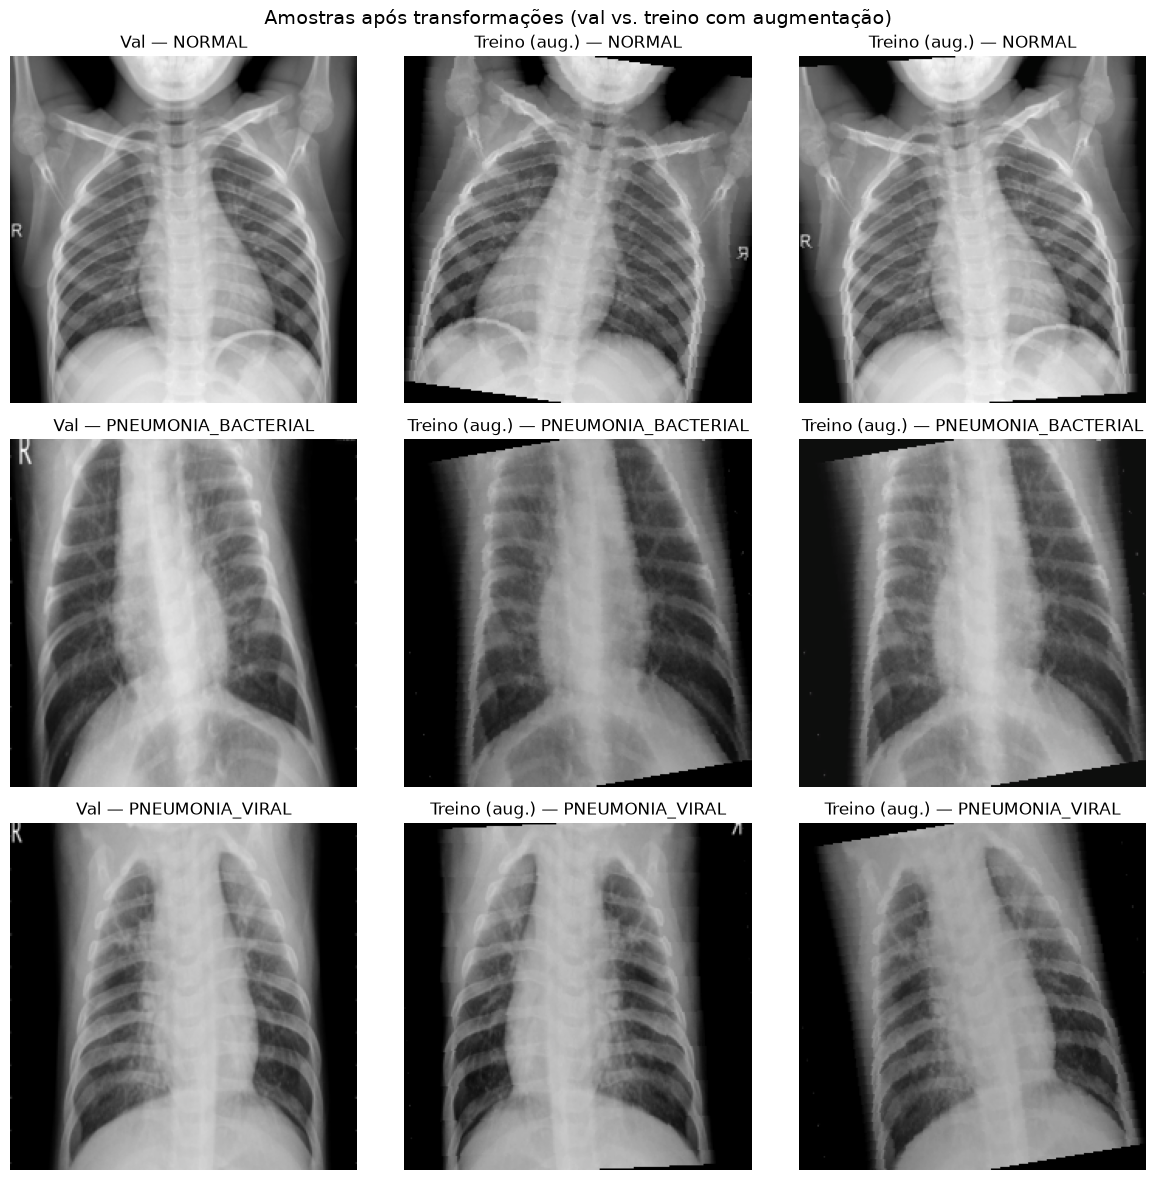

In [3]:
# Visualização de imagens após as transformações
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

def tensor_to_display(tensor):
    img = tensor.cpu().numpy().transpose(1, 2, 0)
    img = img * std + mean
    return np.clip(img, 0, 1)

# Uma amostra de cada classe
indices_by_class = {}
for idx in train_idx:
    label = targets[idx]
    if label not in indices_by_class:
        indices_by_class[label] = idx

fig, axes = plt.subplots(len(class_names), 3, figsize=(12, 4 * len(class_names)))
for row, class_id in enumerate(sorted(indices_by_class.keys())):
    idx = indices_by_class[class_id]
    name = class_names[class_id]

    val_img, _ = val_base_dataset[idx]
    axes[row, 0].imshow(tensor_to_display(val_img), cmap='gray')
    axes[row, 0].set_title(f'Val — {name}')
    axes[row, 0].axis('off')

    for col in range(1, 3):
        train_img, _ = full_train_dataset[idx]
        axes[row, col].imshow(tensor_to_display(train_img), cmap='gray')
        axes[row, col].set_title(f'Treino (aug.) — {name}')
        axes[row, col].axis('off')

plt.suptitle('Amostras após transformações (val vs. treino com augmentação)', fontsize=14)
plt.tight_layout()
plt.show()

### Cálculo de Pesos das Classes

In [4]:
# Cálculo dos pesos base
train_classes = [targets[i] for i in train_idx]
class_counts = Counter(train_classes)
num_classes = len(class_names)
total_samples = len(train_classes)

base_weights_list = [total_samples / (num_classes * class_counts[i]) for i in range(num_classes)]

# V3: Multiplicador de Risco Clínico [NORMAL, BACTERIANA, VIRAL]
penalidade_clinica = [1.0, 3.0, 3.0]
final_weights = [base * pen for base, pen in zip(base_weights_list, penalidade_clinica)]
class_weights = torch.FloatTensor(final_weights).to(device)

print(f"Pesos Finais da V3: {class_weights.cpu().numpy()}")

Pesos Finais da V3: [1.2928637 2.0615764 3.8894053]


### Construção do Vision Transformer

In [5]:
def create_vit_model(num_classes=3, freeze_features=True):
    model = vit_b_16(weights=ViT_B_16_Weights.DEFAULT)
    
    if freeze_features:
        for param in model.parameters():
            param.requires_grad = False
            
    # O classificador do ViT fica em 'heads.head'
    in_features = model.heads.head.in_features
    model.heads.head = nn.Sequential(
        nn.Dropout(p=0.5),
        nn.Linear(in_features, num_classes)
    )
    return model

model_vit = create_vit_model(num_classes=num_classes).to(device)

# A Loss recebe os pesos penalizados calculados na célula anterior
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model_vit.heads.head.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

print("Modelo ViT V3, Critério e Otimizador inicializados com sucesso.")

Modelo ViT V3, Critério e Otimizador inicializados com sucesso.


### Loop de Treinamento

In [6]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=15):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Época {epoch+1}/{num_epochs} \n' + '-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            # Barra de progresso iterativa
            progress_bar = tqdm(dataloaders[phase], desc=f"{phase.capitalize()} Epoch {epoch+1}", leave=False)

            for inputs, labels in progress_bar:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
                
                # Atualiza a loss visual na barra
                progress_bar.set_postfix({'loss': f"{loss.item():.4f}"})

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase.capitalize()} - Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'val':
                scheduler.step(epoch_loss)
                
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
        print()

    time_elapsed = time.time() - since
    print(f'Treinamento completo em {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Melhor Acurácia de Validação: {best_acc:.4f}')

    model.load_state_dict(best_model_wts)
    return model

### Execução do Treinamento

In [ ]:
print("A iniciar o treinamento do Vision Transformer (ViT)...")
model_vit = train_model(model_vit, criterion, optimizer, scheduler, num_epochs=10)

torch.save(model_vit.state_dict(), 'vitV3_pneumonia_best.pth')
print("Pesos do Transformer guardados com sucesso em 'vitV3_pneumonia_best.pth'")

A iniciar o treinamento do Vision Transformer (ViT)...
Época 1/10 
----------


Train Epoch 1:   0%|          | 0/131 [00:21<?, ?it/s]

Train - Loss: 0.7382 Acc: 0.6526


Val Epoch 1:   0%|          | 0/33 [00:15<?, ?it/s]

Val - Loss: 0.6723 Acc: 0.7622

Época 2/10 
----------


...

Val - Loss: 0.5484 Acc: 0.7708

Época 10/10 
----------


Train Epoch 10:   0%|          | 0/131 [00:07<?, ?it/s]

Train - Loss: 0.5900 Acc: 0.7460


Val Epoch 10:   0%|          | 0/33 [00:08<?, ?it/s]

Val - Loss: 0.5871 Acc: 0.7947

Treinamento completo em 30m 32s
Melhor Acurácia de Validação: 0.7966
Pesos do Transformer guardados com sucesso em 'vitV3_pneumonia_best.pth'


### Avaliação no Conjunto de Testes


A iniciar inferência no conjunto de teste...


A testar:   0%|          | 0/20 [00:00<?, ?it/s]


Relatório de Classificação:

                     precision    recall  f1-score   support

             NORMAL       0.95      0.62      0.75       234
PNEUMONIA_BACTERIAL       0.78      0.96      0.86       242
    PNEUMONIA_VIRAL       0.63      0.74      0.68       148

           accuracy                           0.78       624
          macro avg       0.79      0.77      0.76       624
       weighted avg       0.81      0.78      0.78       624



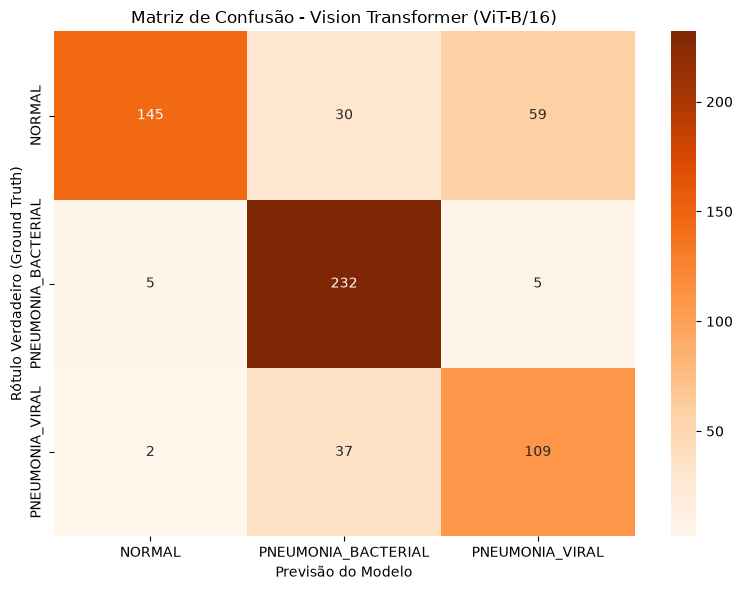

In [9]:
model_vit.load_state_dict(torch.load('vitV3_pneumonia_best.pth'))
model_vit.to(device)

def evaluate_and_plot(model, test_loader, class_names):
    model.eval()
    y_true, y_pred = [], []
    
    print("\nA iniciar inferência no conjunto de teste...")
    with torch.no_grad(): # Desativa o cálculo de gradientes para poupar memória
        for inputs, labels in tqdm(test_loader, desc="A testar", leave=False):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            
    print("\nRelatório de Classificação:\n")
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    # Plot da Matriz de Confusão
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Matriz de Confusão - Vision Transformer (ViT-B/16)')
    plt.ylabel('Rótulo Verdadeiro (Ground Truth)')
    plt.xlabel('Previsão do Modelo')
    plt.tight_layout()
    plt.show()

# Chama a função de avaliação
evaluate_and_plot(model_vit, test_loader, class_names)

### Grad-CAM — Mapas de Calor


A gerar mapas de calor Grad-CAM...


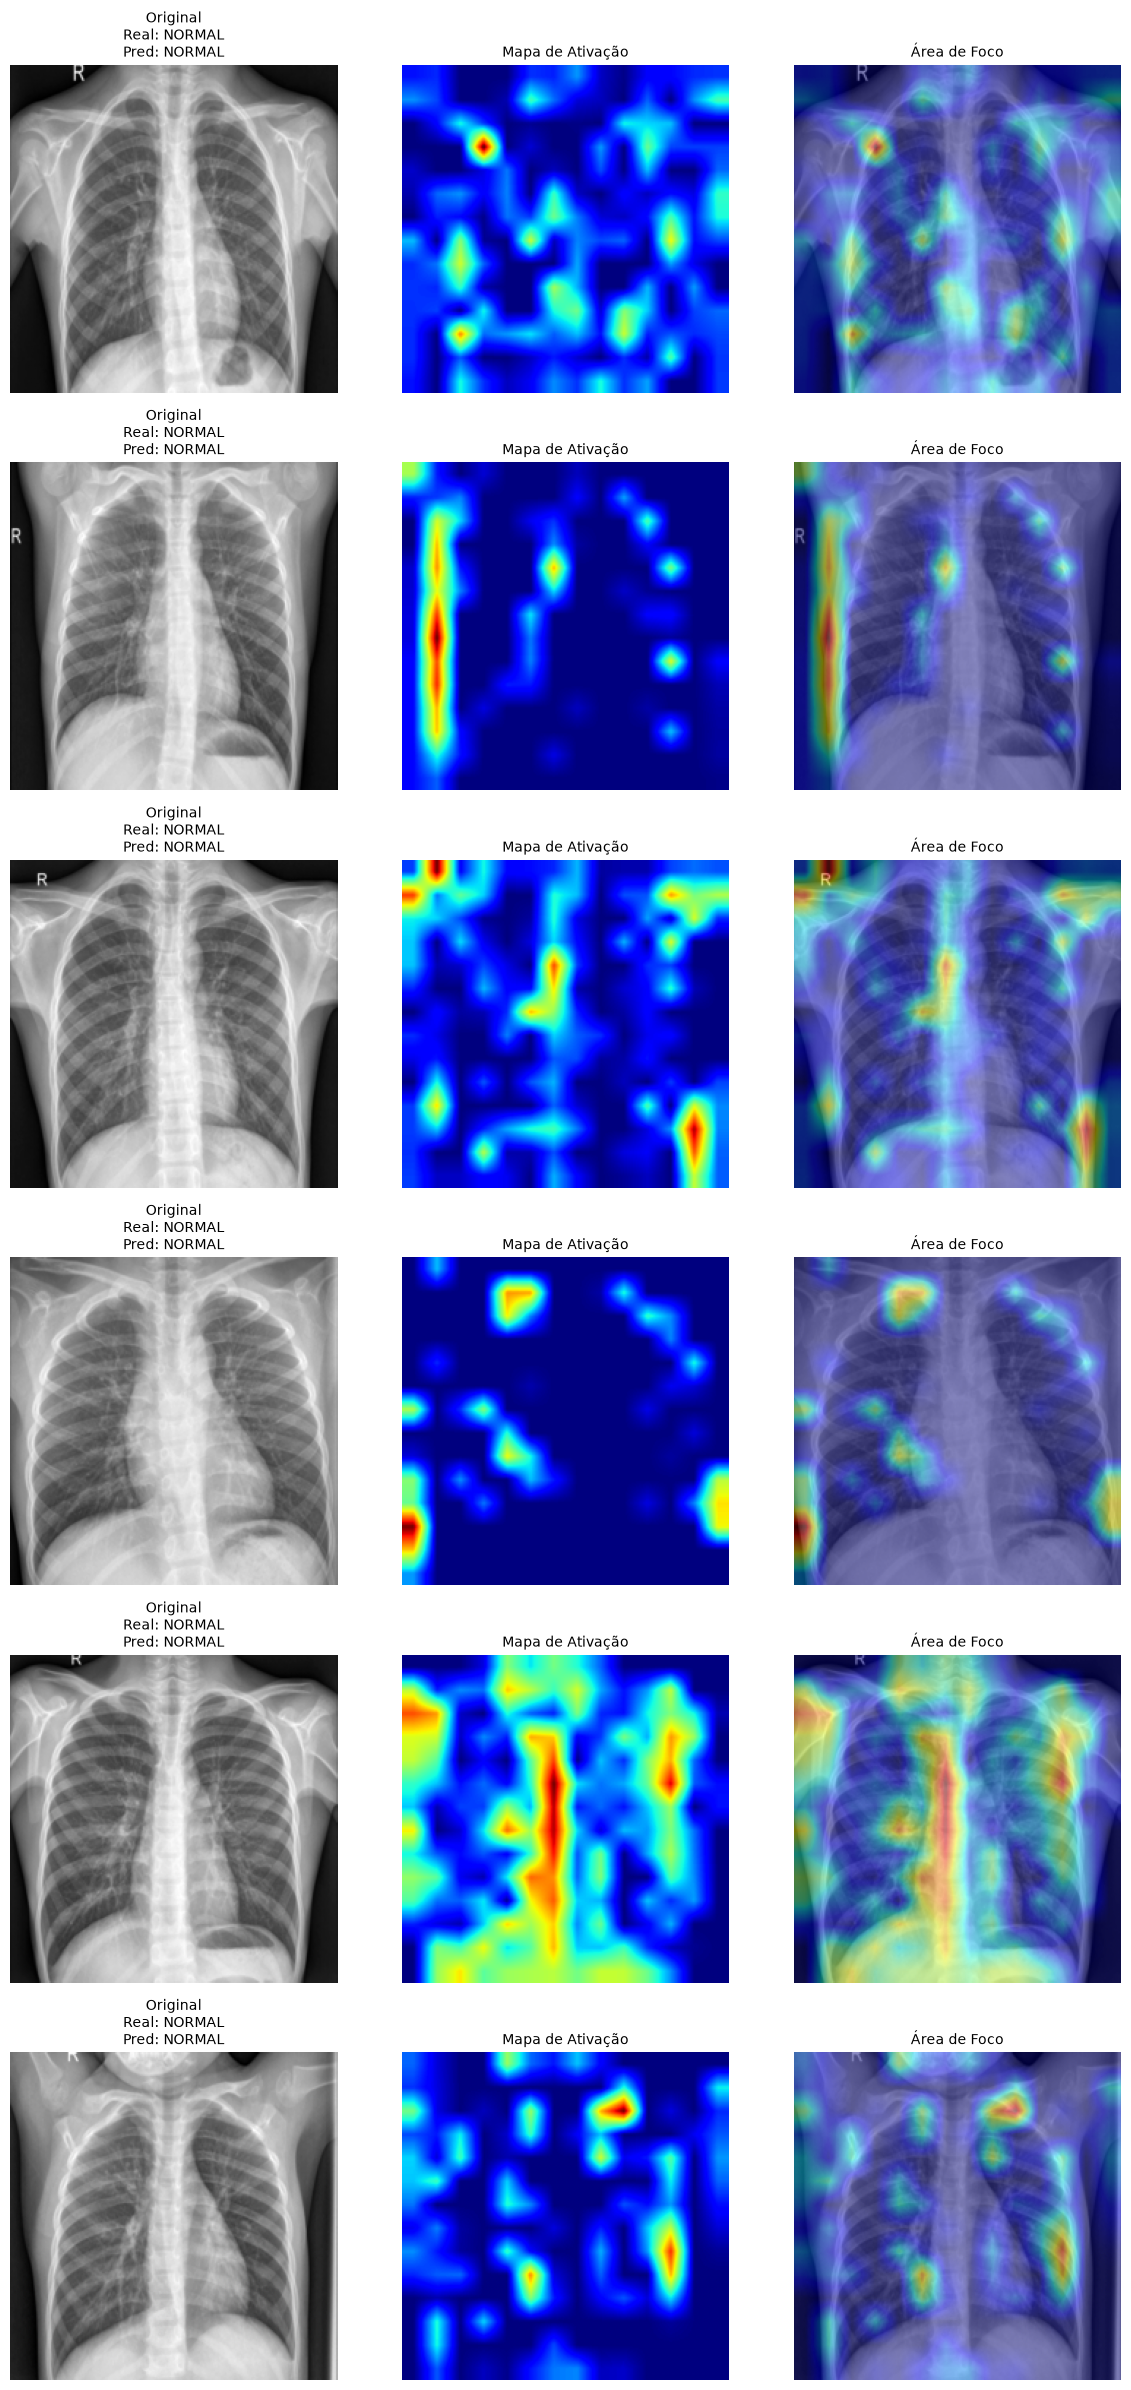

In [10]:
import cv2
import torch.nn.functional as F

class ViTGradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients = None

        for module in self.model.modules():
            if hasattr(module, 'inplace'):
                module.inplace = False

        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate_cam(self, input_tensor, target_class=None):
        self.model.eval()
        self.model.zero_grad()

        input_tensor.requires_grad_(True)
        logits = self.model(input_tensor)

        if target_class is None:
            target_class = logits.argmax(dim=1).item()

        score = logits[0, target_class]
        score.backward()

        if self.gradients is None or self.activations is None:
            raise RuntimeError("Grad-CAM falhou: gradientes não capturados.")

        activations = self.activations.detach()
        gradients = self.gradients.detach()

        weights = gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * activations).sum(dim=1).squeeze()
        cam = F.relu(cam)

        cam = cam.cpu().numpy()
        cam = cv2.resize(cam, (224, 224))
        cam = (cam - np.min(cam)) / (np.max(cam) - np.min(cam) + 1e-8)

        return cam, target_class

def tensor_to_rgb(tensor):
    image = tensor.detach().cpu().numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    image = std * image + mean
    image = np.clip(image, 0, 1)
    return image

def visualize_gradcam(model, test_loader, class_names, num_images=6):
    print("\nA gerar mapas de calor Grad-CAM...")

    # Camada de projeção de patches do ViT (última representação espacial)
    target_layer = model.conv_proj
    cam_extractor = ViTGradCAM(model, target_layer)

    fig, axes = plt.subplots(num_images, 3, figsize=(12, 4 * num_images))
    images_shown = 0

    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.numpy()

        for i in range(inputs.size(0)):
            if images_shown >= num_images:
                break

            img_tensor = inputs[i].unsqueeze(0)
            true_label = labels[i]

            cam, pred_label = cam_extractor.generate_cam(img_tensor)
            title = f"Real: {class_names[true_label]}\nPred: {class_names[pred_label]}"

            gray = tensor_to_rgb(img_tensor[0]).mean(axis=2)
            row = axes[images_shown]

            row[0].imshow(gray, cmap='gray')
            row[0].set_title(f'Original\n{title}', fontsize=10)
            row[0].axis('off')

            row[1].imshow(cam, cmap='jet')
            row[1].set_title('Mapa de Ativação', fontsize=10)
            row[1].axis('off')

            row[2].imshow(gray, cmap='gray')
            row[2].imshow(cam, cmap='jet', alpha=0.45)
            row[2].set_title('Área de Foco', fontsize=10)
            row[2].axis('off')

            images_shown += 1

        if images_shown >= num_images:
            break

    plt.tight_layout()
    plt.show()

visualize_gradcam(model_vit, test_loader, class_names, num_images=6)